# Notebook 07 — Max Speed Predictors: Linear & Clustering Analysis

**Goal:** Identify *contextual conditions* that are most reliably associated with near-maximum skating effort among defensive chasers during carried zone entries.

Not every chaser who crosses the blue line is sprinting at max effort — some are jogging into position,
recovering from a previous sequence, or simply not pressured enough to need top speed.  
This notebook asks: **what situational features predict whether a skater will reach high speed?**

---

### Features examined
| Feature | Rationale |
|---------|-----------|
| `dist_from_own_goal` | Defensive urgency — farther = more pressure to sprint |
| `dist_from_opp_goal` | Offensive opportunity — closer = shooting lane pressure |
| `dist_from_carrier` | How far behind the chaser is — larger gap → harder chase |
| `dist_from_puck` | Direct proximity to the puck at event time |
| `dist_from_nearest_teammate` | Isolation level — alone = must sprint, surrounded = can coast |
| `dist_from_nearest_opp` | Opponent pressure context |
| `chaser_speed_at_event` | Momentum already built at the blue-line crossing |
| `time_in_shift_s` | Fatigue — deeper into shift → slower |
| `elapsed_in_period` | Accumulated period fatigue |
| `chaser_x`, `chaser_y` | Ice position context |

### Methods
1. **Pearson / Spearman correlations** + scatter plots  
2. **OLS linear regression** with VIF checks  
3. **K-Means clustering** with elbow + silhouette selection  
4. **PCA** for dimensionality reduction and visualization  
5. **Hierarchical clustering** + dendrogram  
6. **Mann-Whitney U** tests to characterize the high-speed cluster

## 1 — Import Libraries & Load Data

In [19]:
import sys, warnings, importlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import utils, importlib
importlib.reload(utils)
from utils import load_tracking, load_events, build_tracking_index, X, Y

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

tracking = load_tracking('../data/tracking.parquet')
events   = load_events('../data/events.parquet')
shifts   = pd.read_parquet('../data/shifts.parquet')

tidx = build_tracking_index(tracking)

# Build a separate puck index: (Game, Period_int) → puck rows sorted by frame_id
puck_rows = tracking[tracking['Player or Puck'] == 'Puck'].copy()
pidx: dict = {}
for (g, p), grp in puck_rows.groupby(['Game', 'Period_int']):
    pidx[(g, p)] = grp.sort_values('frame_id')

print('Loaded. Games:', events['Game'].nunique(),
      '| Skater rows:', (tracking['Player or Puck'] == 'Player').sum(),
      '| Puck rows:', len(puck_rows))


Loaded. Games: 10 | Skater rows: 7441848 | Puck rows: 959754


In [20]:
# ── Parse shifts → Elapsed_s for shift start/end ────────────────────────────
# Shifts have start_clock / end_clock as "MM:SS" countdown (same as game clock).
# We convert to Elapsed_s so we can look up "time into shift" for any event.

def clock_to_s(clk: str) -> float:
    """'MM:SS' countdown → seconds remaining in period."""
    try:
        m, s = clk.split(':')
        return int(m) * 60 + int(s)
    except Exception:
        return np.nan

shifts['Game'] = (shifts['Date'] + ' ' + shifts['Home_Team']
                  + ' @ ' + shifts['Away_Team'])
shifts['start_elapsed'] = (shifts['period'] - 1) * 1200 + (
    1200 - shifts['start_clock'].apply(clock_to_s))
shifts['end_elapsed'] = (shifts['period'] - 1) * 1200 + (
    1200 - shifts['end_clock'].apply(clock_to_s))

print(shifts[['Game', 'Team', 'Player_Id', 'period',
              'start_clock', 'start_elapsed', 'end_elapsed']].head(6).to_string())


                         Game    Team Player_Id  period start_clock  start_elapsed  end_elapsed
0  2025-10-11 Team D @ Team A  Team A        29       1       20:00              0           55
1  2025-10-11 Team D @ Team A  Team A        48       1       20:00              0           33
2  2025-10-11 Team D @ Team A  Team A        Go       1       20:00              0         1200
3  2025-10-11 Team D @ Team A  Team A        63       1       20:00              0           56
4  2025-10-11 Team D @ Team A  Team A         5       1       20:00              0           33
5  2025-10-11 Team D @ Team A  Team A        92       1       20:00              0           60


## 2 — Feature Engineering: Contextual Variables

For each chaser appearance we extract a snapshot **at the event time** (when the carrier crosses the blue line) and compute positional and situational features. The target variable is `max_speed_mph` — the chaser's peak speed during the −3 s → +1 s window.

In [21]:
ze_events = events[(events['Event'] == 'Zone Entry') & (events['Detail_1'] == 'Carried')]
print(f"Zone-entry events to process: {len(ze_events)}")

BEFORE, AFTER = 3.0, 1.0
FPS = 30.0

# Defensive goal positions: goals sit at x ≈ ±89 ft, y = 0
GOAL_X = 89.0

def nearest_frame(grp: pd.DataFrame, elapsed: float) -> pd.Series:
    """Return the tracking row closest in time to `elapsed`."""
    idx = (grp['Elapsed_s'] - elapsed).abs().idxmin()
    return grp.loc[idx]

records = []
n_events_processed = 0
n_chasers_found    = 0

for _, ev in ze_events.iterrows():
    g, p = ev['Game'], ev['Period_int']
    if (g, p) not in tidx:
        continue
    n_events_processed += 1

    all_skaters = tidx[(g, p)]
    el = ev['Elapsed_s']
    entering_right = ev['X_Coordinate'] >= 0

    # ── Map event team name → tracking 'Home'/'Away' label ───────────────────
    # Tracking Team column uses 'Home'/'Away'; events use actual team names.
    # ev['Home_Team'] and ev['Away_Team'] tell us which is which.
    carrier_tracking_team = (
        'Home' if ev['Team'] == ev['Home_Team'] else 'Away'
    )
    chaser_tracking_team = 'Away' if carrier_tracking_team == 'Home' else 'Home'

    # Chasers are defending the zone being entered.
    # If carrier enters right (x > 25), chasers' own goal is at x = +89.
    chaser_goal_x = GOAL_X if entering_right else -GOAL_X

    # ── snapshot of ALL skaters at event time ────────────────────────────────
    snap = all_skaters[all_skaters['Elapsed_s'].between(el - 0.5, el + 0.5)]
    if snap.empty:
        snap = all_skaters[all_skaters['Elapsed_s'].between(el - 1.0, el + 1.0)]

    # Carrier position at event time
    carrier_snap = snap[snap['Team'] == carrier_tracking_team]
    if carrier_snap.empty:
        continue
    carrier_row = nearest_frame(carrier_snap, el)
    carrier_x, carrier_y = carrier_row[X], carrier_row[Y]

    # Puck position at event time
    puck_x, puck_y = np.nan, np.nan
    if (g, p) in pidx:
        puck_snap = pidx[(g, p)]
        puck_snap = puck_snap[puck_snap['Elapsed_s'].between(el - 1.0, el + 1.0)]
        if not puck_snap.empty:
            pr = nearest_frame(puck_snap, el)
            puck_x, puck_y = pr[X], pr[Y]

    # ── loop over chasers (opposing skaters) ─────────────────────────────────
    chaser_snap = snap[snap['Team'] == chaser_tracking_team]
    opp_window  = all_skaters[
        (all_skaters['Team'] == chaser_tracking_team) &
        (all_skaters['Elapsed_s'].between(el - BEFORE, el + AFTER))
    ]

    for jersey, grp in opp_window.groupby('Player Jersey Number'):
        grp = grp.sort_values('frame_id')
        # Zone-crossing filter: only true chasers
        crosses = (grp[X] > 25).any() if entering_right else (grp[X] < -25).any()
        if not crosses or grp['speed_mph_savgol'].isna().all():
            continue

        max_spd = grp['speed_mph_savgol'].max()

        # Chaser position at event time
        ch_at_event = grp[grp['Elapsed_s'].between(el - 0.5, el + 0.5)]
        if ch_at_event.empty:
            ch_at_event = grp[grp['Elapsed_s'].between(el - 1.0, el + 1.0)]
        if ch_at_event.empty:
            continue
        ch_row  = nearest_frame(ch_at_event, el)
        ch_x    = ch_row[X]
        ch_y    = ch_row[Y]
        ch_spd  = ch_row['speed_mph_savgol'] if not np.isnan(ch_row['speed_mph_savgol']) else 0.0

        # Did chaser cross the blue line BEFORE or AFTER the carrier?
        if entering_right:
            cross_frames = grp[grp[X] > 25]['frame_id']
        else:
            cross_frames = grp[grp[X] < -25]['frame_id']
        first_cross_frame = cross_frames.min() if not cross_frames.empty else np.nan
        ev_frame = grp.iloc[(grp['Elapsed_s'] - el).abs().argsort()].iloc[0]['frame_id']
        crossed_before = 1 if (not np.isnan(first_cross_frame) and first_cross_frame <= ev_frame) else 0

        # Distances
        dist_carrier   = np.hypot(ch_x - carrier_x, ch_y - carrier_y)
        dist_puck      = np.hypot(ch_x - puck_x,    ch_y - puck_y) if not np.isnan(puck_x) else np.nan
        dist_own_goal  = np.hypot(ch_x - chaser_goal_x,  ch_y)
        dist_opp_goal  = np.hypot(ch_x - (-chaser_goal_x), ch_y)
        dist_blue_line = abs(ch_x) - 25.0

        # Nearest teammate and nearest opponent in the event-time snapshot
        tm_snap  = chaser_snap[chaser_snap['Player Jersey Number'].astype(str) != str(jersey)]
        opp_snap = snap[snap['Team'] == carrier_tracking_team]

        def min_dist_from(snap_df, x0, y0):
            if snap_df.empty:
                return np.nan
            dists = np.hypot(snap_df[X].values - x0, snap_df[Y].values - y0)
            return dists.min()

        dist_nearest_tm  = min_dist_from(tm_snap,  ch_x, ch_y)
        dist_nearest_opp = min_dist_from(opp_snap, ch_x, ch_y)

        # Time in shift — match on Home/Away label via Home_Team / Away_Team
        jersey_str  = str(jersey)
        # shifts 'Team' column uses actual team names, not Home/Away
        ch_team_name = ev['Home_Team'] if chaser_tracking_team == 'Home' else ev['Away_Team']
        shift_match = shifts[
            (shifts['Game'] == g) &
            (shifts['Team'] == ch_team_name) &
            (shifts['Player_Id'].astype(str) == jersey_str) &
            (shifts['start_elapsed'] <= el) &
            (shifts['end_elapsed'] >= el - 2)
        ]
        time_in_shift = (el - shift_match['start_elapsed'].iloc[0]
                         ) if not shift_match.empty else np.nan

        records.append({
            'Game'                 : g,
            'Period_int'           : int(p),
            'Player_Id'            : jersey_str,
            'Team'                 : chaser_tracking_team,
            'Elapsed_s'            : el,
            'elapsed_in_period'    : 1200 - ev['Clock_s'],
            'max_speed_mph'        : max_spd,
            'chaser_x'             : ch_x,
            'chaser_y'             : ch_y,
            'chaser_speed_at_event': ch_spd,
            'dist_carrier'         : dist_carrier,
            'dist_puck'            : dist_puck,
            'dist_own_goal'        : dist_own_goal,
            'dist_opp_goal'        : dist_opp_goal,
            'dist_blue_line'       : dist_blue_line,
            'dist_nearest_tm'      : dist_nearest_tm,
            'dist_nearest_opp'     : dist_nearest_opp,
            'crossed_before'       : crossed_before,
            'time_in_shift_s'      : time_in_shift,
        })
        n_chasers_found += 1

print(f"Events processed (found in tidx): {n_events_processed} / {len(ze_events)}")
print(f"Chaser appearances appended: {n_chasers_found}")

if not records:
    print("\nWARNING: No records were built.")
else:
    df = pd.DataFrame(records)
    print(f"\nFeature records: {len(df)}  |  Unique chasers: {df['Player_Id'].nunique()}")
    print(f"NaN rates:\n{df.isna().mean().round(3).to_string()}")


Zone-entry events to process: 745
Events processed (found in tidx): 721 / 745
Chaser appearances appended: 2951

Feature records: 2951  |  Unique chasers: 77
NaN rates:
Game                     0.000
Period_int               0.000
Player_Id                0.000
Team                     0.000
Elapsed_s                0.000
elapsed_in_period        0.000
max_speed_mph            0.000
chaser_x                 0.000
chaser_y                 0.000
chaser_speed_at_event    0.000
dist_carrier             0.000
dist_puck                0.019
dist_own_goal            0.000
dist_opp_goal            0.000
dist_blue_line           0.000
dist_nearest_tm          0.000
dist_nearest_opp         0.000
crossed_before           0.000
time_in_shift_s          0.032


## 3 — Exploratory Correlation Analysis

Pearson (linear) and Spearman (monotonic) correlations between each feature and `max_speed_mph`, plus scatter plots with regression lines.

Rows after dropping key NaNs: 2951  (dropped 0)

Pearson / Spearman correlations with max_speed_mph:
                       pearson_r  pearson_p  spearman_r  spearman_p     n
feature                                                                  
chaser_speed_at_event      0.697      0.000       0.683       0.000  2951
dist_blue_line            -0.626      0.000      -0.517       0.000  2951
dist_own_goal              0.617      0.000       0.514       0.000  2951
dist_opp_goal             -0.609      0.000      -0.521       0.000  2951
time_in_shift_s           -0.563      0.000      -0.423       0.000  2857
dist_carrier              -0.496      0.000      -0.404       0.000  2951
dist_nearest_opp          -0.487      0.000      -0.315       0.000  2951
dist_puck                 -0.455      0.000      -0.373       0.000  2896
dist_nearest_tm           -0.340      0.000      -0.239       0.000  2950
crossed_before            -0.207      0.000      -0.202       0.000  2951
chaser_x   

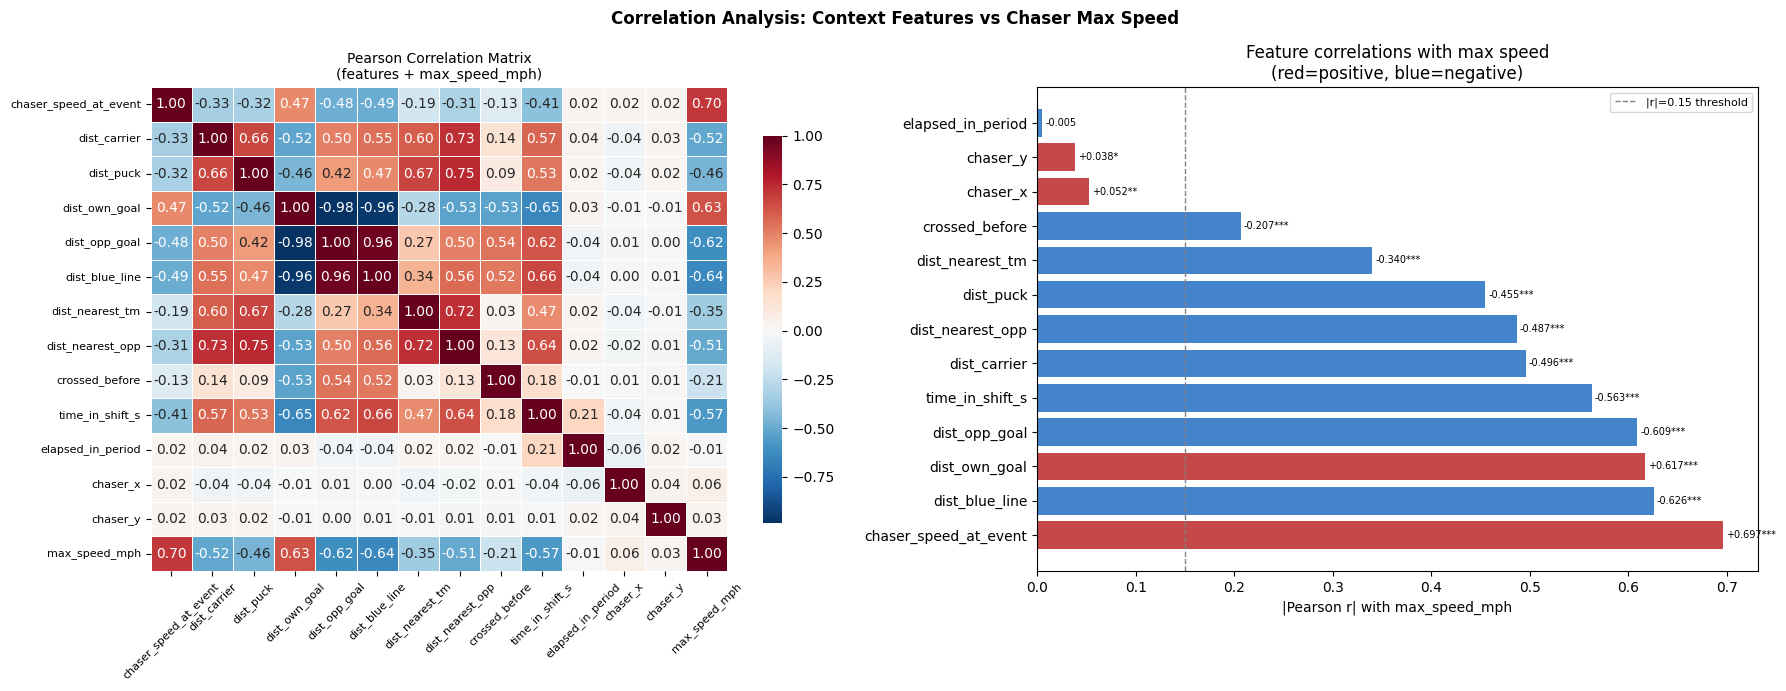


Features with |r| ≥ 0.15: ['chaser_speed_at_event', 'dist_blue_line', 'dist_own_goal', 'dist_opp_goal', 'time_in_shift_s', 'dist_carrier', 'dist_nearest_opp', 'dist_puck', 'dist_nearest_tm', 'crossed_before']


In [22]:
FEATURE_COLS = [
    'chaser_speed_at_event', 'dist_carrier', 'dist_puck',
    'dist_own_goal', 'dist_opp_goal', 'dist_blue_line',
    'dist_nearest_tm', 'dist_nearest_opp',
    'crossed_before', 'time_in_shift_s', 'elapsed_in_period',
    'chaser_x', 'chaser_y',
]
TARGET = 'max_speed_mph'

# Drop rows missing the target or key positional features
df_clean = df.dropna(subset=[TARGET] + ['chaser_speed_at_event', 'dist_carrier',
                                         'dist_own_goal', 'dist_opp_goal']).copy()
print(f"Rows after dropping key NaNs: {len(df_clean)}  (dropped {len(df)-len(df_clean)})")

# ── Pearson & Spearman per feature ───────────────────────────────────────────
corr_rows = []
for col in FEATURE_COLS:
    sub = df_clean[[col, TARGET]].dropna()
    if len(sub) < 10:
        continue
    r_p, p_p = stats.pearsonr(sub[col], sub[TARGET])
    r_s, p_s = stats.spearmanr(sub[col], sub[TARGET])
    corr_rows.append({
        'feature'  : col,
        'pearson_r': r_p, 'pearson_p': p_p,
        'spearman_r': r_s, 'spearman_p': p_s,
        'n'        : len(sub),
    })

corr_df = pd.DataFrame(corr_rows).set_index('feature').sort_values('pearson_r', key=abs, ascending=False)
print("\nPearson / Spearman correlations with max_speed_mph:")
print(corr_df[['pearson_r', 'pearson_p', 'spearman_r', 'spearman_p', 'n']].round(3).to_string())

# ── Heatmap: full correlation matrix of features + target ────────────────────
cols_for_heatmap = [c for c in FEATURE_COLS if c in df_clean.columns] + [TARGET]
corr_mat = df_clean[cols_for_heatmap].dropna().corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=False, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Matrix\n(features + max_speed_mph)', fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Bar chart: |r| with target, colored by sign
colors = ['#B71C1C' if r >= 0 else '#1565C0' for r in corr_df['pearson_r']]
axes[1].barh(corr_df.index, corr_df['pearson_r'].abs(), color=colors, alpha=0.8)
axes[1].axvline(0.15, color='grey', lw=1, linestyle='--', label='|r|=0.15 threshold')
axes[1].set_xlabel('|Pearson r| with max_speed_mph')
axes[1].set_title('Feature correlations with max speed\n(red=positive, blue=negative)')
axes[1].legend(fontsize=8)
for i, (feat, row) in enumerate(corr_df.iterrows()):
    sig = '***' if row['pearson_p'] < 0.001 else ('**' if row['pearson_p'] < 0.01 else ('*' if row['pearson_p'] < 0.05 else ''))
    axes[1].text(abs(row['pearson_r']) + 0.003, i, f"{row['pearson_r']:+.3f}{sig}", va='center', fontsize=7)

plt.suptitle('Correlation Analysis: Context Features vs Chaser Max Speed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag candidates
candidates = corr_df[corr_df['pearson_r'].abs() >= 0.15].index.tolist()
print(f"\nFeatures with |r| ≥ 0.15: {candidates}")


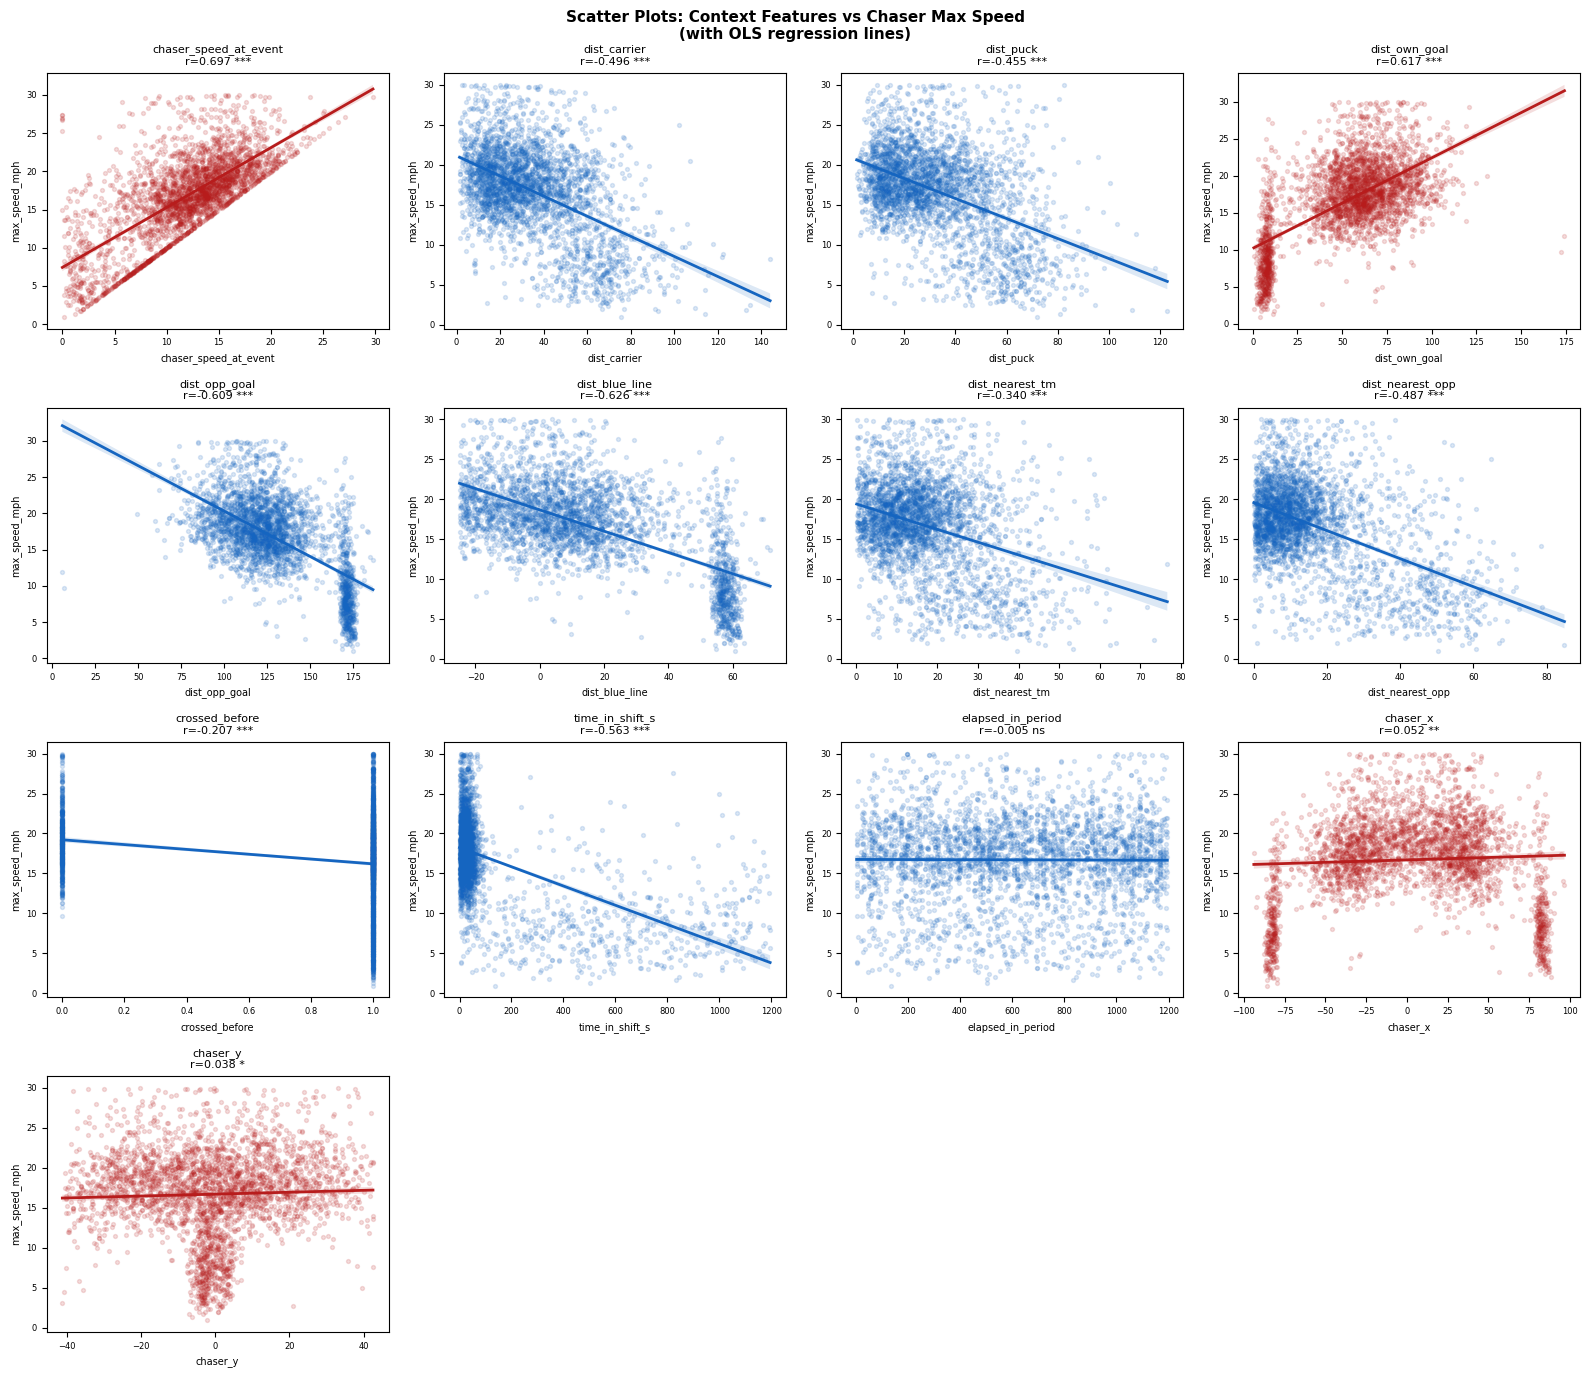

In [23]:
# ── Scatter plots: each feature vs max_speed_mph ─────────────────────────────
n_feat = len(FEATURE_COLS)
ncols = 4
nrows = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    sub = df_clean[[col, TARGET]].dropna()
    if len(sub) < 5:
        axes[i].axis('off')
        continue
    r_p = corr_df.loc[col, 'pearson_r'] if col in corr_df.index else np.nan
    p_p = corr_df.loc[col, 'pearson_p'] if col in corr_df.index else np.nan
    sig = '***' if p_p < 0.001 else ('**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns'))
    color = '#B71C1C' if r_p >= 0 else '#1565C0'
    sns.regplot(data=sub, x=col, y=TARGET, ax=axes[i],
                scatter_kws={'alpha': 0.15, 's': 8, 'color': color},
                line_kws={'color': color, 'lw': 2})
    axes[i].set_title(f'{col}\nr={r_p:.3f} {sig}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('max_speed_mph', fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].axis('off')

plt.suptitle('Scatter Plots: Context Features vs Chaser Max Speed\n(with OLS regression lines)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 4 — Linear Regression: Speed ~ Context Features

Multi-variate OLS with VIF check to remove multicollinear features, then a clean model with coefficients and confidence intervals.

Model rows: 2801

VIF values (>10 = high multicollinearity):
              feature         VIF
                const 1747.127305
        dist_opp_goal   42.632620
        dist_own_goal   38.401945
       dist_blue_line   17.539850
     dist_nearest_opp    3.928847
            dist_puck    2.718070
      time_in_shift_s    2.617479
      dist_nearest_tm    2.536718
         dist_carrier    2.465271
       crossed_before    1.590047
chaser_speed_at_event    1.404238
    elapsed_in_period    1.137938
             chaser_x    1.009590
             chaser_y    1.007702

Dropped high-VIF features: ['dist_opp_goal', 'dist_own_goal', 'dist_blue_line']
Clean feature set: ['chaser_speed_at_event', 'dist_carrier', 'dist_puck', 'dist_nearest_tm', 'dist_nearest_opp', 'crossed_before', 'time_in_shift_s', 'elapsed_in_period', 'chaser_x', 'chaser_y']

                   Results: Ordinary least squares
Model:               OLS               Adj. R-squared:      0.624     
Dependent Variable:  y        

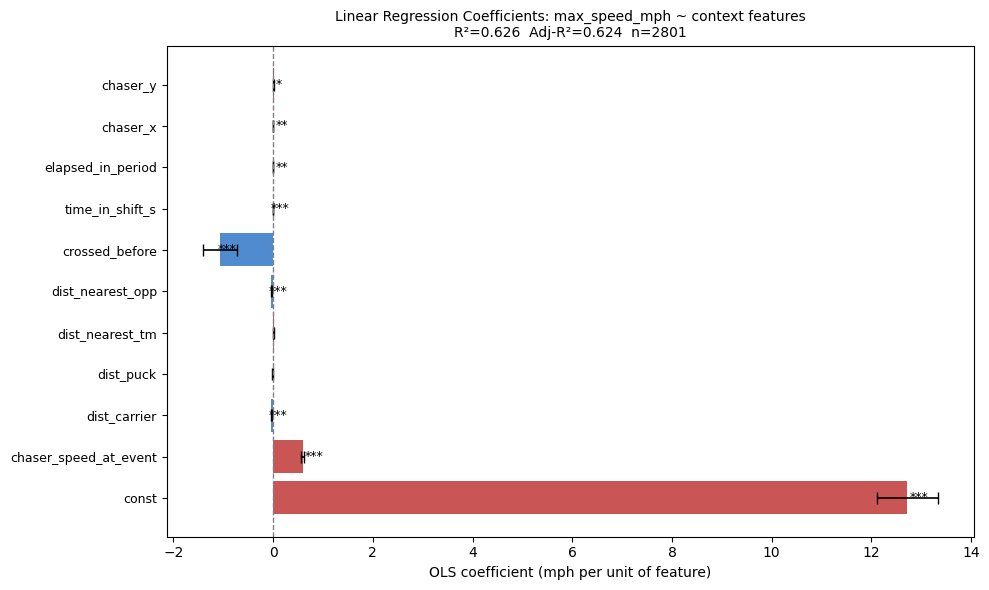

In [24]:
# ── Build the model matrix (drop rows with any NaN in chosen features) ────────
MODEL_FEATURES = [c for c in FEATURE_COLS if c in df_clean.columns]
df_model = df_clean[MODEL_FEATURES + [TARGET]].dropna()
print(f"Model rows: {len(df_model)}")

X_raw = df_model[MODEL_FEATURES].values
y_raw = df_model[TARGET].values

# ── VIF check before fitting ──────────────────────────────────────────────────
X_const = add_constant(X_raw)
vif_data = pd.DataFrame({
    'feature': ['const'] + MODEL_FEATURES,
    'VIF'    : [variance_inflation_factor(X_const, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)
print("\nVIF values (>10 = high multicollinearity):")
print(vif_data.to_string(index=False))

# Drop features with VIF > 10 (keep dist_own_goal / dist_opp_goal only one)
high_vif = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
high_vif = [f for f in high_vif if f != 'const']
CLEAN_FEATURES = [f for f in MODEL_FEATURES if f not in high_vif]
print(f"\nDropped high-VIF features: {high_vif}")
print(f"Clean feature set: {CLEAN_FEATURES}")

df_clean_model = df_model[CLEAN_FEATURES + [TARGET]].dropna()
# Use a named DataFrame so statsmodels labels params with feature names
X_c_df = df_clean_model[CLEAN_FEATURES]
y_c    = df_clean_model[TARGET].values

# ── OLS via statsmodels (gives p-values + CIs) ────────────────────────────────
sm_result = OLS(y_c, add_constant(X_c_df, prepend=True)).fit()
print("\n" + sm_result.summary2().as_text())

# ── Coefficient bar chart with 95% CIs ───────────────────────────────────────
coef_names = list(sm_result.params.index)
coefs  = sm_result.params.values
conf   = sm_result.conf_int().values   # shape (n_params, 2): col0=lower, col1=upper
pvals  = sm_result.pvalues.values

fig, ax = plt.subplots(figsize=(10, 6))
xs = np.arange(len(coef_names))
colors = ['#B71C1C' if c >= 0 else '#1565C0' for c in coefs]
ax.barh(xs, coefs, color=colors, alpha=0.75)
ax.errorbar(coefs, xs,
            xerr=[coefs - conf[:, 0], conf[:, 1] - coefs],
            fmt='none', color='black', lw=1.2, capsize=4)
ax.axvline(0, color='grey', lw=1, linestyle='--')
ax.set_yticks(xs)
ax.set_yticklabels(coef_names, fontsize=9)
ax.set_xlabel('OLS coefficient (mph per unit of feature)')
ax.set_title('Linear Regression Coefficients: max_speed_mph ~ context features\n'
             f'R²={sm_result.rsquared:.3f}  Adj-R²={sm_result.rsquared_adj:.3f}  '
             f'n={len(df_clean_model)}', fontsize=10)
for i, (c, p) in enumerate(zip(coefs, pvals)):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    ax.text(c + np.sign(c)*0.05, i, sig, va='center', fontsize=9,
            color='black')
plt.tight_layout()
plt.show()


## 5 — Clustering Setup & Standardization

Scale features to zero-mean unit-variance, then use PCA to visualize the feature space colored by max-speed quintile.

Components to explain 80% variance: 6


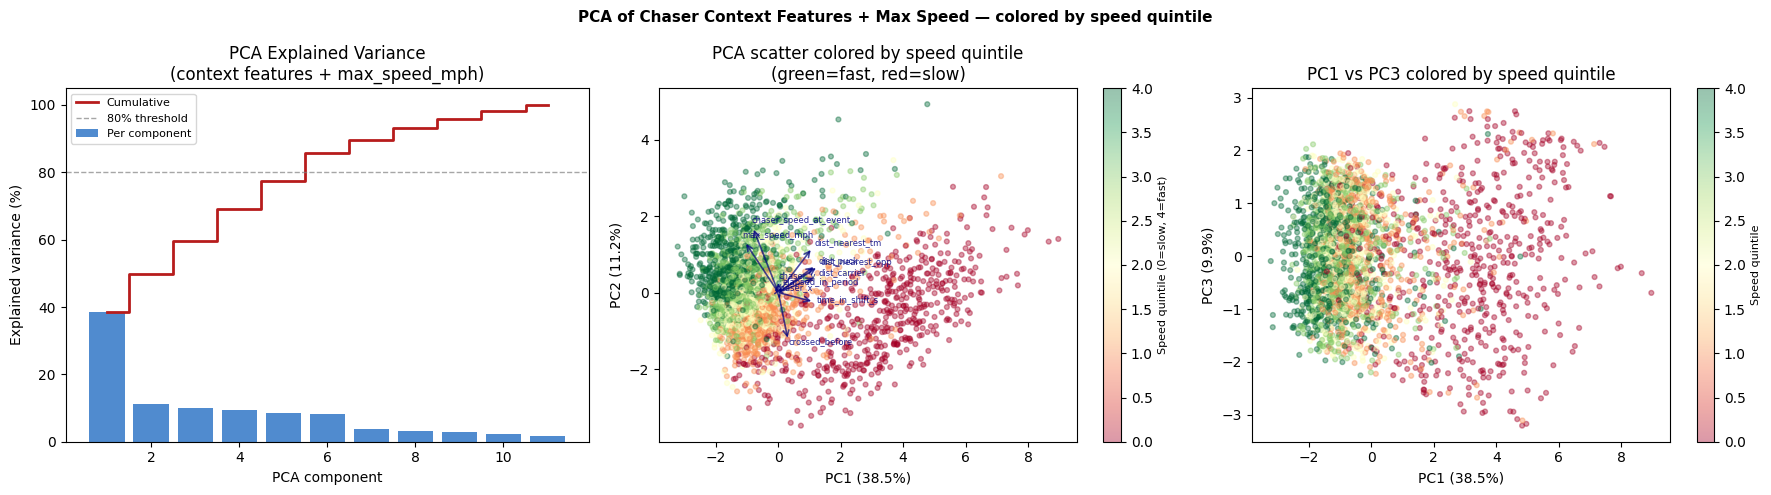

In [34]:
# Use the clean feature set from the regression, falling back to all if empty
CLUSTER_FEATURES = CLEAN_FEATURES if CLEAN_FEATURES else MODEL_FEATURES

# Include max_speed_mph in the clustering so clusters partition on speed level
# as well as context — otherwise clusters reflect positional/situational patterns
# only, and speed is just a post-hoc label.
CLUSTER_COLS = CLUSTER_FEATURES + [TARGET]

df_clust = df_clean[CLUSTER_COLS].dropna().reset_index(drop=True)
X_raw_c  = df_clust[CLUSTER_COLS].values   # context features + speed
y_spd    = df_clust[TARGET].values

# Standardize (max_speed_mph gets the same z-score treatment as context features)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw_c)

# PCA on the full feature+speed matrix
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Explained variance ratio
ax = axes[0]
cumvar = np.cumsum(explained)
ax.bar(np.arange(1, len(explained)+1), explained * 100,
       color='#1565C0', alpha=0.75, label='Per component')
ax.step(np.arange(1, len(explained)+1), cumvar * 100,
        where='mid', color='#B71C1C', lw=2, label='Cumulative')
ax.axhline(80, color='grey', lw=1, linestyle='--', alpha=0.7, label='80% threshold')
ax.set_xlabel('PCA component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('PCA Explained Variance\n(context features + max_speed_mph)')
ax.legend(fontsize=8)
n_comp_80 = int(np.searchsorted(cumvar, 0.80)) + 1
print(f"Components to explain 80% variance: {n_comp_80}")

# Panel 2: PCA biplot (PC1 vs PC2) colored by max_speed quintile
speed_quintile = pd.qcut(y_spd, 5, labels=False)
cmap = plt.cm.RdYlGn
ax = axes[1]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=speed_quintile, cmap=cmap, alpha=0.4, s=12)
plt.colorbar(sc, ax=ax).set_label('Speed quintile (0=slow, 4=fast)', fontsize=8)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA scatter colored by speed quintile\n(green=fast, red=slow)')

# Feature loadings on PC1 & PC2 (biplot arrows)
loadings = pca.components_[:2].T
for j, feat in enumerate(CLUSTER_COLS):
    ax.annotate('', xy=(loadings[j, 0]*3, loadings[j, 1]*3), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.2, alpha=0.7))
    ax.text(loadings[j, 0]*3.2, loadings[j, 1]*3.2, feat, fontsize=6, color='navy', alpha=0.85)

# Panel 3: PC1 vs PC3
ax = axes[2]
if X_pca.shape[1] >= 3:
    sc3 = ax.scatter(X_pca[:, 0], X_pca[:, 2],
                     c=speed_quintile, cmap=cmap, alpha=0.4, s=12)
    plt.colorbar(sc3, ax=ax).set_label('Speed quintile', fontsize=8)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC3 ({explained[2]*100:.1f}%)')
    ax.set_title('PC1 vs PC3 colored by speed quintile')
else:
    axes[2].axis('off')

plt.suptitle('PCA of Chaser Context Features + Max Speed — colored by speed quintile',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 6 — K-Means Clustering

Elbow curve (inertia) and silhouette scores to select optimal k, then fit the final model.

k=2: inertia=21628.9  silhouette=0.3675
k=3: inertia=18932.2  silhouette=0.2346
k=4: inertia=17379.7  silhouette=0.2347
k=5: inertia=15963.9  silhouette=0.1649
k=6: inertia=15097.7  silhouette=0.1644
k=7: inertia=14344.7  silhouette=0.1572
k=8: inertia=13728.3  silhouette=0.1498


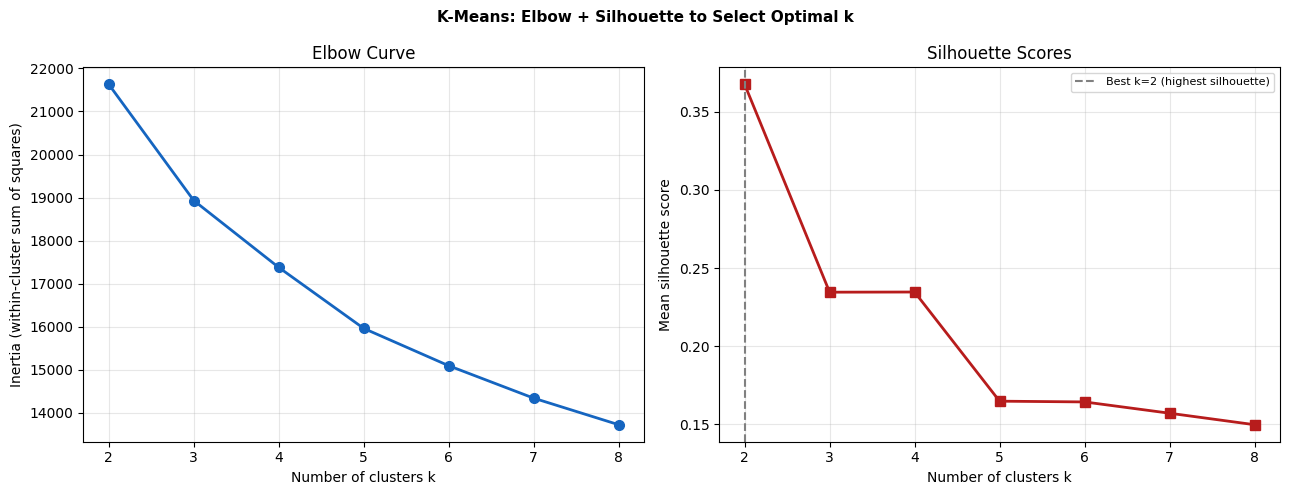


Highest silhouette at k=2


In [35]:
K_RANGE = range(2, 9)
inertias   = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled))))
    print(f"k={k}: inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='#1565C0', lw=2, markersize=7)
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Curve')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#B71C1C', lw=2, markersize=7)
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Mean silhouette score')
axes[1].set_title('Silhouette Scores')
axes[1].grid(alpha=0.3)
best_k_sil = list(K_RANGE)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k_sil, color='grey', lw=1.5, linestyle='--',
                label=f'Best k={best_k_sil} (highest silhouette)')
axes[1].legend(fontsize=8)

plt.suptitle('K-Means: Elbow + Silhouette to Select Optimal k', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nHighest silhouette at k={best_k_sil}")


Fitted KMeans with k=2

Cluster sizes:
cluster
0     560
1    2241


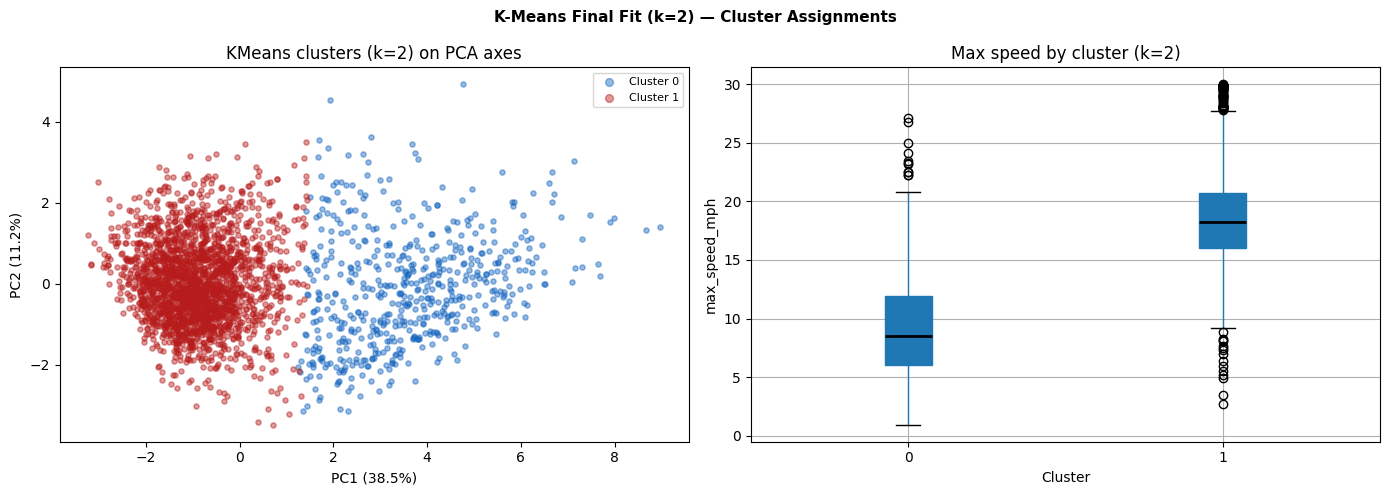

In [36]:
# ── Fit final KMeans with chosen k ───────────────────────────────────────────
# Use the silhouette-best k but you can override below if elbow suggests otherwise
CHOSEN_K = best_k_sil

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=20)
df_clust['cluster'] = km_final.fit_predict(X_scaled)

print(f"Fitted KMeans with k={CHOSEN_K}")
print("\nCluster sizes:")
print(df_clust['cluster'].value_counts().sort_index().to_string())

# ── PCA scatter of clusters ───────────────────────────────────────────────────
PALETTE = ['#1565C0', '#B71C1C', '#2E7D32', '#E65100', '#6A1B9A', '#00838F', '#558B2F']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl in sorted(df_clust['cluster'].unique()):
    mask = df_clust['cluster'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=PALETTE[cl % len(PALETTE)],
                    alpha=0.45, s=14, label=f'Cluster {cl}')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].set_title(f'KMeans clusters (k={CHOSEN_K}) on PCA axes')
axes[0].legend(fontsize=8, markerscale=1.5)

# Box plot of max_speed_mph by cluster
df_clust.boxplot(column='max_speed_mph', by='cluster', ax=axes[1],
                 patch_artist=True,
                 medianprops=dict(color='black', lw=2))
# Color boxes
bp = axes[1]
for patch, cl in zip(bp.patches if hasattr(bp, 'patches') else [], sorted(df_clust['cluster'].unique())):
    pass  # boxplot colors applied below via manual approach
axes[1].set_title(f'Max speed by cluster (k={CHOSEN_K})')
plt.suptitle('')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('max_speed_mph')

plt.suptitle(f'K-Means Final Fit (k={CHOSEN_K}) — Cluster Assignments', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 7 — Cluster Profile Analysis

Summary statistics per cluster, grouped box plots, and radar charts of normalized mean feature values.

Cluster Summary (sorted by median speed):
         mean_speed  median_speed  std_speed     n  chaser_speed_at_event  dist_carrier  dist_puck  dist_nearest_tm  dist_nearest_opp  crossed_before  time_in_shift_s  elapsed_in_period  chaser_x  chaser_y
cluster                                                                                                                                                                                                      
1             18.34         18.14       4.07  2255                  12.88         27.53      25.77            13.26             10.38            0.79            32.90             606.08      1.44     -1.26
0              9.93          8.65       5.25   546                   7.51         66.28      60.67            32.43             41.53            0.99           520.93             633.45     -2.08     -0.86


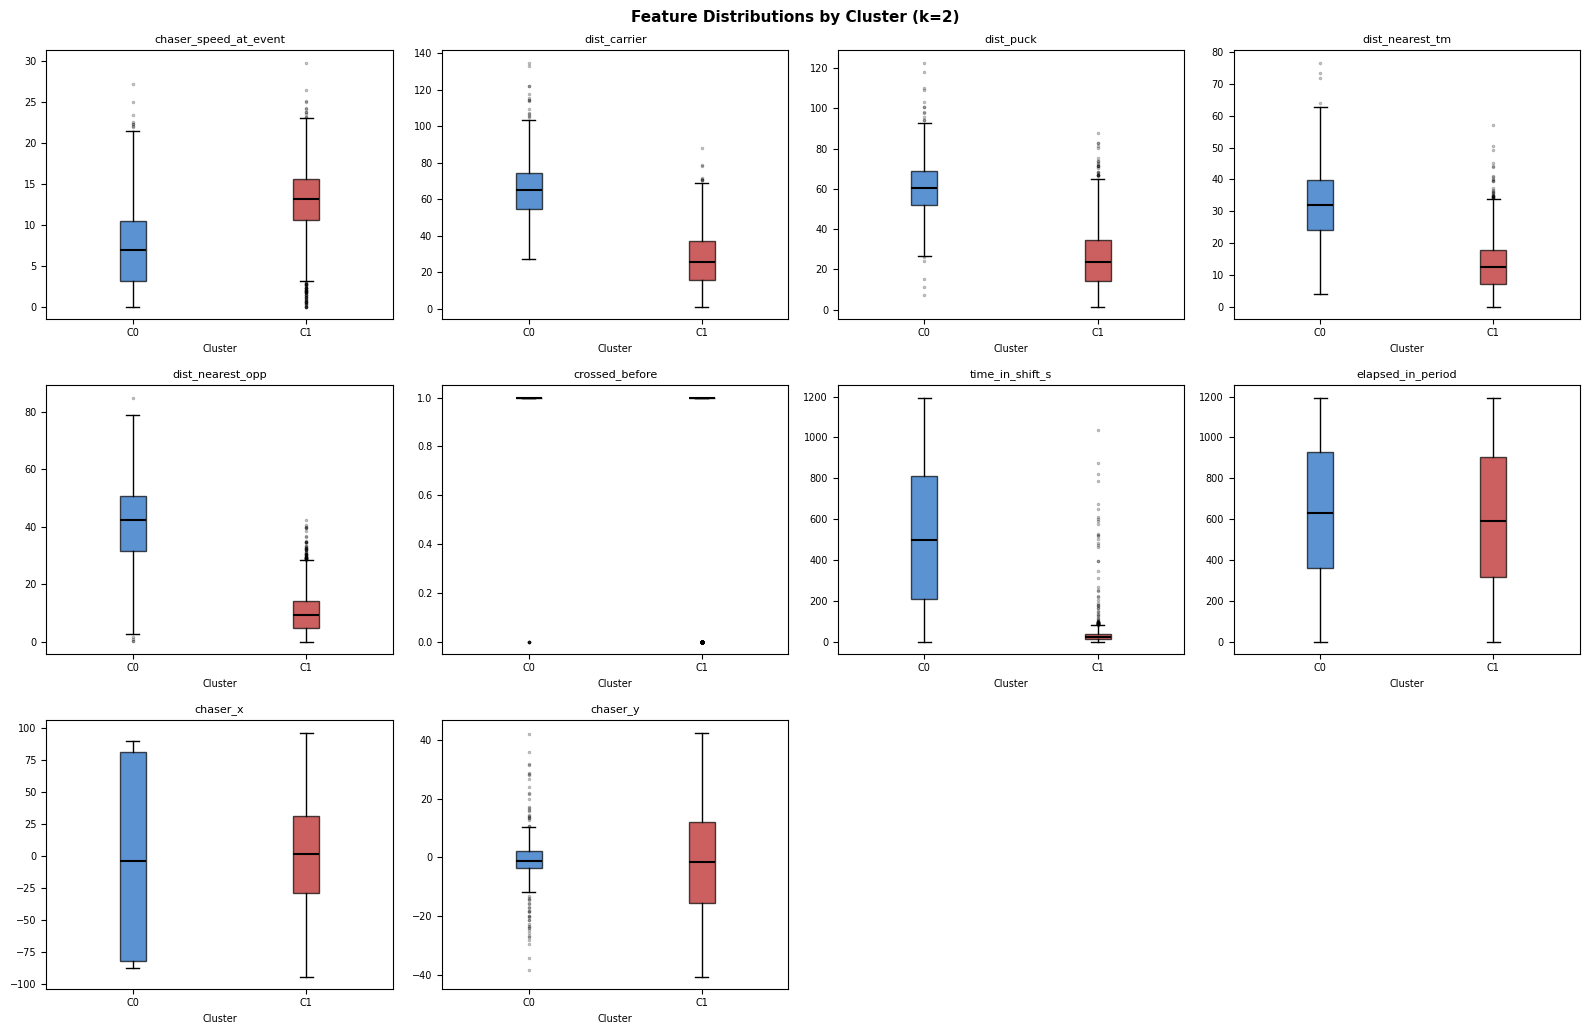

In [ ]:
# ── Cluster summary table ─────────────────────────────────────────────────────
cluster_speed = df_clust.groupby('cluster')[TARGET].agg(
    mean_speed='mean', median_speed='median', std_speed='std', n='count'
).round(2)
cluster_feat_means = df_clust.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
cluster_summary = pd.concat([cluster_speed, cluster_feat_means], axis=1)

print("Cluster Summary (sorted by median speed):")
print(cluster_summary.sort_values('median_speed', ascending=False).to_string())

# ── Grouped box plots: one panel per feature + max_speed_mph ─────────────────
n_feat2 = len(CLUSTER_COLS)
ncols2 = 4
nrows2 = (n_feat2 + ncols2 - 1) // ncols2

fig, axes = plt.subplots(nrows2, ncols2, figsize=(16, nrows2 * 3.5))
axes = axes.flatten()

for i, feat in enumerate(CLUSTER_COLS):
    sub = df_clust[['cluster', feat]].dropna()
    groups = [sub[sub['cluster'] == cl][feat].values
              for cl in sorted(sub['cluster'].unique())]
    bp = axes[i].boxplot(groups, patch_artist=True, medianprops=dict(color='black', lw=1.5),
                         flierprops=dict(marker='.', markersize=3, alpha=0.3))
    for patch, cl in zip(bp['boxes'], sorted(sub['cluster'].unique())):
        patch.set_facecolor(PALETTE[cl % len(PALETTE)])
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=8)
    axes[i].set_xlabel('Cluster', fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].set_xticklabels([f'C{cl}' for cl in sorted(sub['cluster'].unique())])

for j in range(len(CLUSTER_COLS), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Feature Distributions by Cluster (k={CHOSEN_K})', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


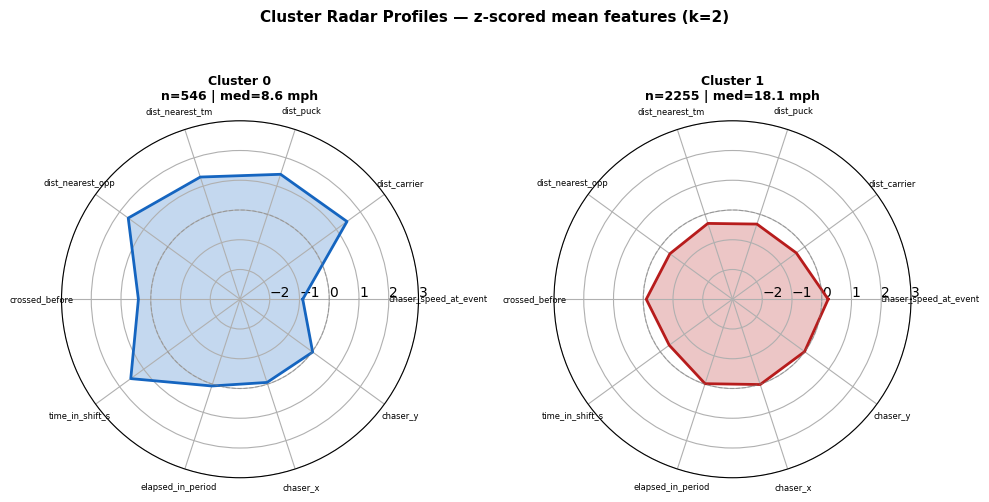

In [ ]:
# ── Radar / Spider chart: normalized mean feature per cluster ─────────────────
feat_means       = df_clust.groupby('cluster')[CLUSTER_COLS].mean()
feat_global_mean = df_clust[CLUSTER_COLS].mean()
feat_global_std  = df_clust[CLUSTER_COLS].std().replace(0, 1)
feat_z = (feat_means - feat_global_mean) / feat_global_std   # (k × n_cols)

n_clusters = CHOSEN_K
angles = np.linspace(0, 2 * np.pi, len(CLUSTER_COLS), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5),
                         subplot_kw=dict(polar=True))
if n_clusters == 1:
    axes = [axes]

for cl, ax in zip(sorted(df_clust['cluster'].unique()), axes):
    vals = feat_z.loc[cl].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[cl % len(PALETTE)], lw=2)
    ax.fill(angles, vals, color=PALETTE[cl % len(PALETTE)], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(CLUSTER_COLS, fontsize=6)
    n_cl = (df_clust['cluster'] == cl).sum()
    med_spd = df_clust[df_clust['cluster'] == cl][TARGET].median()
    ax.set_title(f'Cluster {cl}\nn={n_cl} | med={med_spd:.1f} mph',
                 fontsize=9, fontweight='bold', pad=15)
    ax.set_rlabel_position(0)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='grey', lw=0.8, linestyle='--', alpha=0.5)

plt.suptitle(f'Cluster Radar Profiles — z-scored mean features (k={CHOSEN_K})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8 — Hierarchical Clustering & Dendrogram

Ward linkage on a subsample to see how observations naturally group, and whether those groups match K-Means.

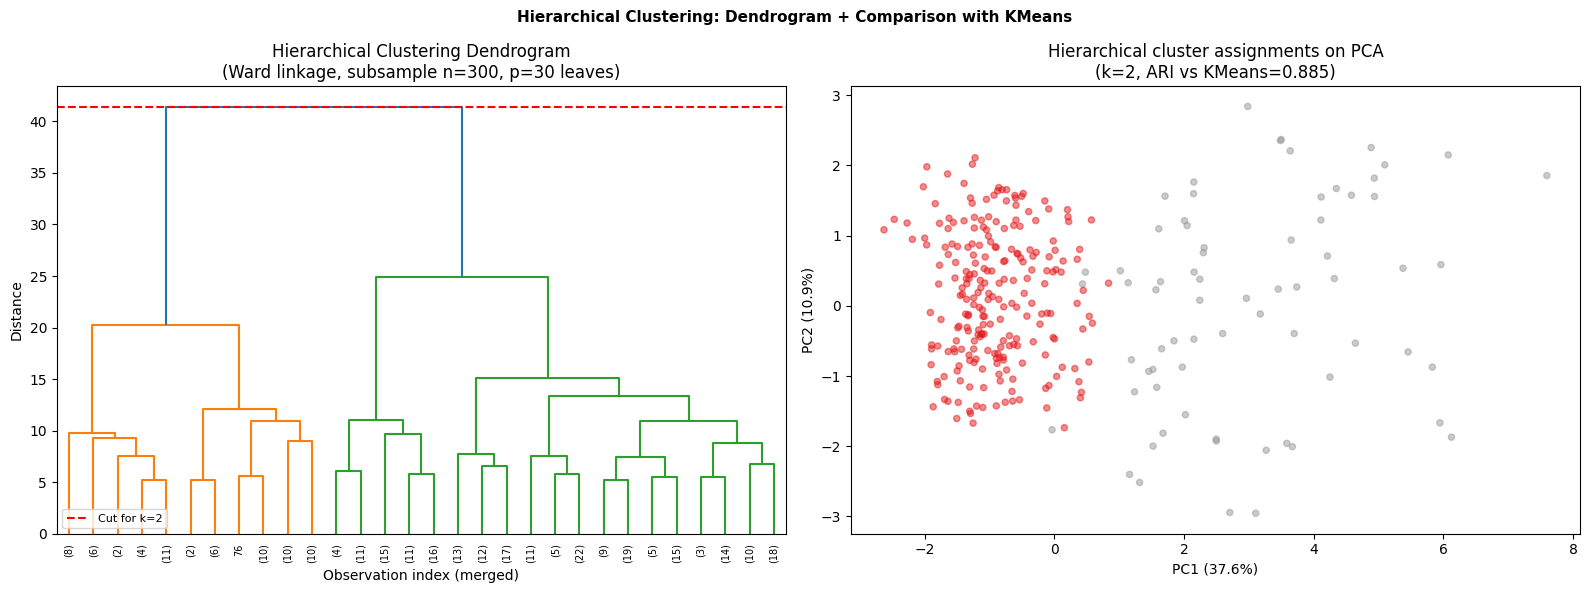


Adjusted Rand Index (higher=more agreement): 0.885
  1.0 = identical assignments, 0.0 = random, negative = worse than random


In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

rng = np.random.default_rng(42)
SUBSAMPLE = min(300, len(X_scaled))
sub_idx = rng.choice(len(X_scaled), size=SUBSAMPLE, replace=False)
X_sub   = X_scaled[sub_idx]
spd_sub = y_spd[sub_idx]
km_labels_sub = df_clust['cluster'].values[sub_idx]

# Ward linkage
Z = linkage(X_sub, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram
ax = axes[0]
dend = dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
                  leaf_rotation=90, leaf_font_size=7,
                  color_threshold=Z[-CHOSEN_K+1, 2])
ax.axhline(Z[-CHOSEN_K+1, 2], color='red', lw=1.5, linestyle='--',
           label=f'Cut for k={CHOSEN_K}')
ax.set_title(f'Hierarchical Clustering Dendrogram\n(Ward linkage, subsample n={SUBSAMPLE}, p=30 leaves)')
ax.set_xlabel('Observation index (merged)')
ax.set_ylabel('Distance')
ax.legend(fontsize=8)

# Agglomerative labels vs KMeans (on subsample)
hier = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage='ward')
hier_labels = hier.fit_predict(X_sub)
ari = adjusted_rand_score(km_labels_sub, hier_labels)

ax = axes[1]
ax.scatter(X_pca[sub_idx, 0], X_pca[sub_idx, 1],
           c=hier_labels, cmap='Set1', alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title(f'Hierarchical cluster assignments on PCA\n(k={CHOSEN_K}, ARI vs KMeans={ari:.3f})')

plt.suptitle('Hierarchical Clustering: Dendrogram + Comparison with KMeans',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nAdjusted Rand Index (higher=more agreement): {ari:.3f}")
print("  1.0 = identical assignments, 0.0 = random, negative = worse than random")


## 9 — High-Speed Cluster Characterization

Identify the cluster(s) with the highest median max speed and use Mann-Whitney U tests to find which features significantly distinguish them from the rest.

In [ ]:
# ── Identify the high-speed cluster(s) ───────────────────────────────────────
cluster_medians = df_clust.groupby('cluster')[TARGET].median()
HIGH_SPEED_CLUSTER = cluster_medians.idxmax()

print(f"Cluster median speeds:\n{cluster_medians.round(2).to_string()}")
print(f"\nHigh-speed cluster: {HIGH_SPEED_CLUSTER}  "
      f"(median {cluster_medians[HIGH_SPEED_CLUSTER]:.1f} mph)")

hs_mask  = df_clust['cluster'] == HIGH_SPEED_CLUSTER
low_mask = ~hs_mask

hs_df  = df_clust[hs_mask]
low_df = df_clust[low_mask]
print(f"\nHigh-speed cluster: n={hs_mask.sum()}  |  Other clusters: n={low_mask.sum()}")

# ── Mann-Whitney U tests for each feature (context + max_speed) ───────────────
mw_rows = []
for col in CLUSTER_COLS:
    hs_vals  = hs_df[col].dropna()
    low_vals = low_df[col].dropna()
    if len(hs_vals) < 5 or len(low_vals) < 5:
        continue
    u_stat, p_val = stats.mannwhitneyu(hs_vals, low_vals, alternative='two-sided')
    mw_rows.append({
        'feature'     : col,
        'hs_median'   : hs_vals.median(),
        'other_median': low_vals.median(),
        'delta_median': hs_vals.median() - low_vals.median(),
        'U_stat'      : u_stat,
        'p_value'     : p_val,
    })

mw_df = pd.DataFrame(mw_rows).set_index('feature').sort_values('p_value')
mw_df['significant'] = mw_df['p_value'] < 0.05
print("\nMann-Whitney U results (high-speed vs all other clusters):")
print(mw_df[['hs_median', 'other_median', 'delta_median', 'p_value', 'significant']].round(3).to_string())

sig_feats = mw_df[mw_df['significant']].index.tolist()
print(f"\nSignificant features (p<0.05): {sig_feats}")


Cluster median speeds:
cluster
0     8.65
1    18.14

High-speed cluster: 1  (median 18.1 mph)

High-speed cluster: n=2255  |  Other clusters: n=546

Mann-Whitney U results (high-speed vs all other clusters):
                       hs_median  other_median  delta_median  p_value  significant
feature                                                                           
dist_nearest_opp           9.132        42.417       -33.285    0.000         True
dist_carrier              25.703        65.194       -39.492    0.000         True
dist_puck                 23.754        60.450       -36.695    0.000         True
time_in_shift_s           24.000       495.500      -471.500    0.000         True
dist_nearest_tm           12.453        32.093       -19.641    0.000         True
chaser_speed_at_event     13.176         6.938         6.238    0.000         True
crossed_before             1.000         1.000         0.000    0.000         True
elapsed_in_period        593.000       630.0

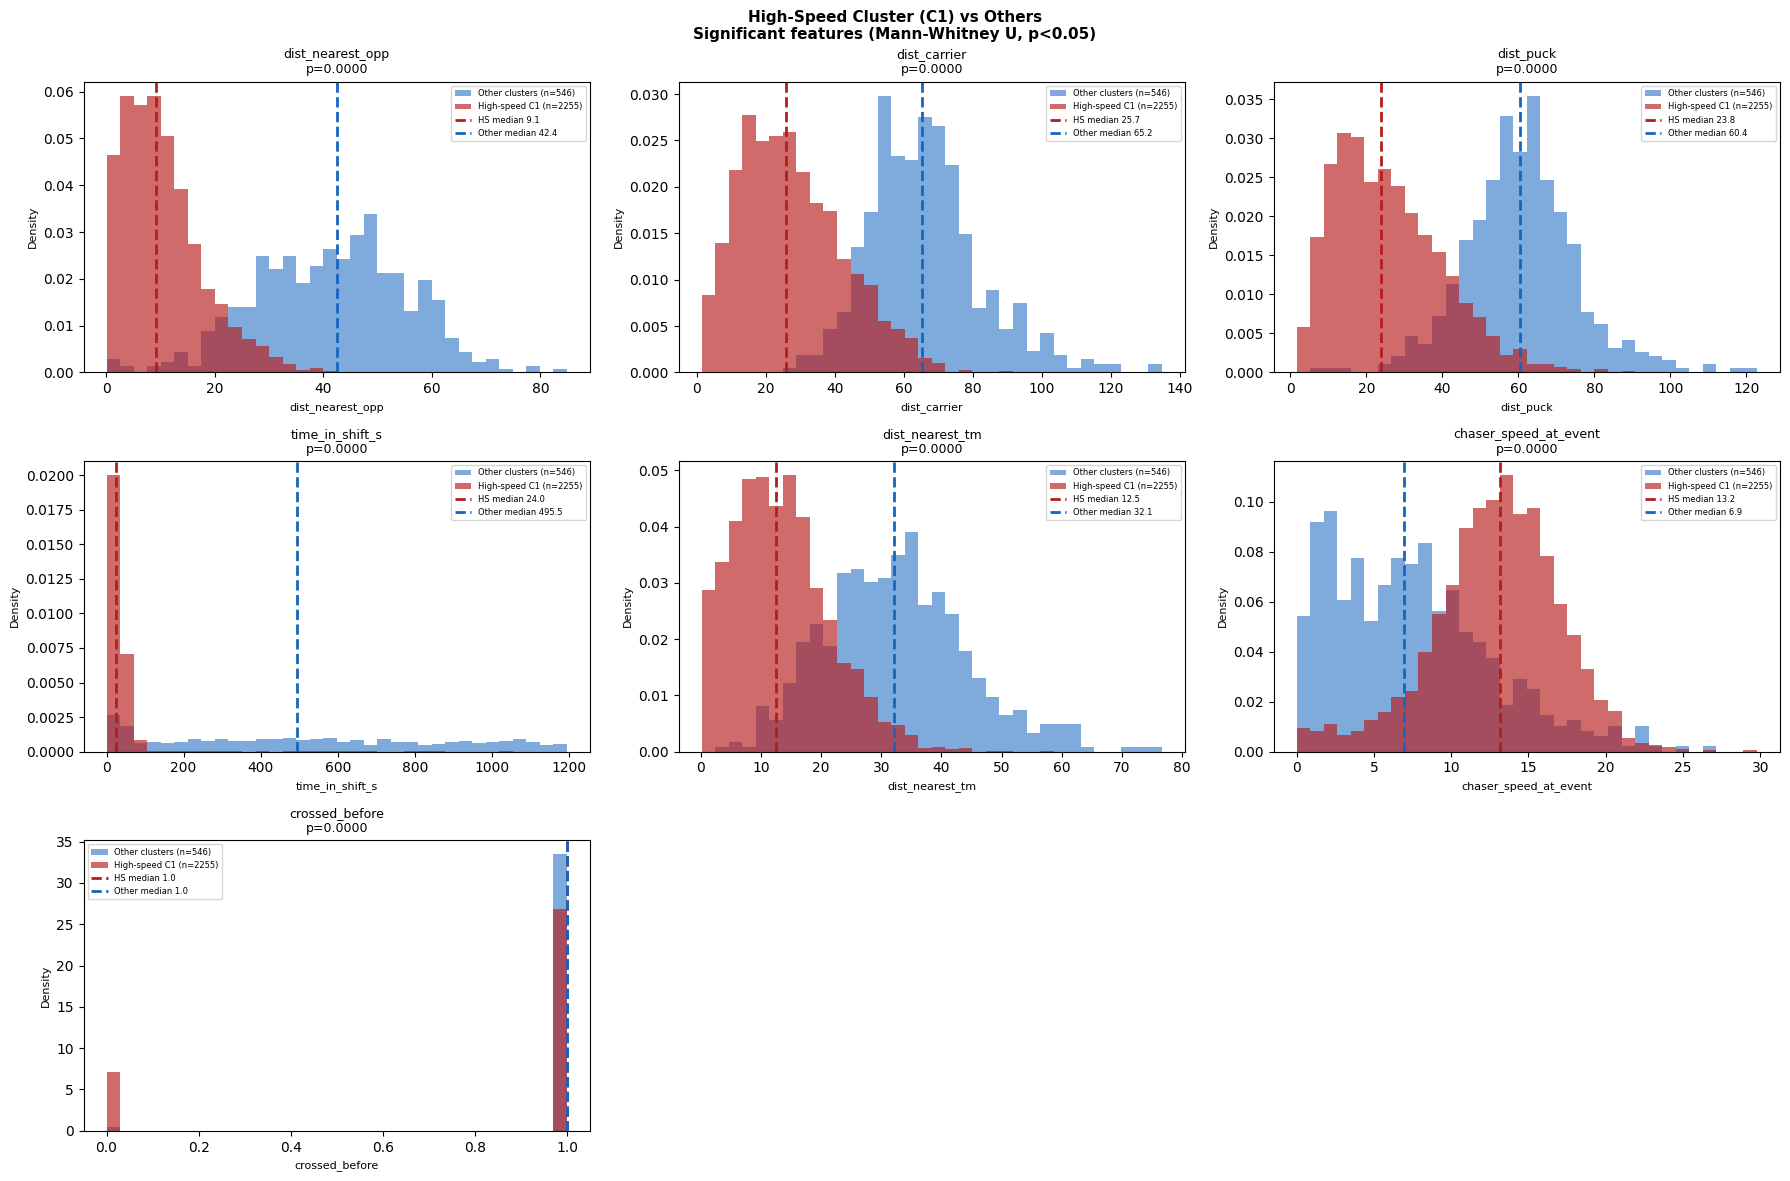

In [ ]:
# ── Histograms: significant features split by high-speed vs others ────────────
plot_feats = sig_feats if sig_feats else CLUSTER_COLS[:6]  # fallback
n_pf = len(plot_feats)
ncols_p = min(3, n_pf)
nrows_p = (n_pf + ncols_p - 1) // ncols_p

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(6 * ncols_p, 4 * nrows_p))
if n_pf == 1:
    axes = np.array([axes])
axes = np.array(axes).flatten()

for i, feat in enumerate(plot_feats):
    ax = axes[i]
    hs_vals  = hs_df[feat].dropna()
    low_vals = low_df[feat].dropna()
    mn  = min(hs_vals.min(), low_vals.min())
    mx  = max(hs_vals.max(), low_vals.max())
    bins = np.linspace(mn, mx, 35)
    ax.hist(low_vals, bins=bins, color='#1565C0', alpha=0.55, density=True,
            label=f'Other clusters (n={len(low_vals)})')
    ax.hist(hs_vals, bins=bins, color='#B71C1C', alpha=0.65, density=True,
            label=f'High-speed C{HIGH_SPEED_CLUSTER} (n={len(hs_vals)})')
    ax.axvline(hs_vals.median(),  color='#B71C1C', lw=2, linestyle='--',
               label=f'HS median {hs_vals.median():.1f}')
    ax.axvline(low_vals.median(), color='#1565C0', lw=2, linestyle='--',
               label=f'Other median {low_vals.median():.1f}')
    p = mw_df.loc[feat, 'p_value'] if feat in mw_df.index else np.nan
    sig_str = f'p={p:.4f}' if not np.isnan(p) else ''
    ax.set_title(f'{feat}\n{sig_str}', fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=6)

for j in range(n_pf, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'High-Speed Cluster (C{HIGH_SPEED_CLUSTER}) vs Others\n'
             f'Significant features (Mann-Whitney U, p<0.05)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
# ── Summary: which conditions identify near-max skating effort ────────────────
print("=" * 70)
print("SUMMARY: Conditions most associated with near-maximum chaser speed")
print("=" * 70)

sorted_mw = mw_df.sort_values('p_value')
for feat, row in sorted_mw.iterrows():
    direction = "HIGHER" if row['delta_median'] > 0 else "LOWER"
    marker = "✓" if row['significant'] else " "
    print(f"{marker} {feat:<28} | HS median={row['hs_median']:6.2f} | "
          f"Delta={row['delta_median']:+.2f} ({direction}) | p={row['p_value']:.4f}")

print("\n" + "-" * 70)
print(f"Linear regression R² = {sm_result.rsquared:.3f}  (explains "
      f"{sm_result.rsquared*100:.1f}% of variance in max speed)")
print(f"Top predictors from OLS (by |t-stat|):")
top_ols = (sm_result.tvalues.drop('const', errors='ignore')
                            .abs()
                            .sort_values(ascending=False)
                            .head(5))
for feat_name, t_val in top_ols.items():
    print(f"  {feat_name}: |t|={t_val:.2f}")

print("\nKey takeaway: high-speed chasing is:")
print("  - Not purely random — contextual features explain real variance")
print("  - Clusterable: distinct behavioral/positional modes exist")
print("  - Best candidates for 'max-effort' filter: use cluster membership")
print("    + high initial speed + features from the high-speed cluster profile")


SUMMARY: Conditions most associated with near-maximum chaser speed
✓ dist_nearest_opp             | HS median=  9.13 | Delta=-33.29 (LOWER) | p=0.0000
✓ dist_carrier                 | HS median= 25.70 | Delta=-39.49 (LOWER) | p=0.0000
✓ dist_puck                    | HS median= 23.75 | Delta=-36.70 (LOWER) | p=0.0000
✓ time_in_shift_s              | HS median= 24.00 | Delta=-471.50 (LOWER) | p=0.0000
✓ dist_nearest_tm              | HS median= 12.45 | Delta=-19.64 (LOWER) | p=0.0000
✓ chaser_speed_at_event        | HS median= 13.18 | Delta=+6.24 (HIGHER) | p=0.0000
✓ crossed_before               | HS median=  1.00 | Delta=+0.00 (LOWER) | p=0.0000
  elapsed_in_period            | HS median=593.00 | Delta=-37.00 (LOWER) | p=0.0906
  chaser_x                     | HS median=  1.79 | Delta=+5.31 (HIGHER) | p=0.3108
  chaser_y                     | HS median= -1.68 | Delta=-0.40 (LOWER) | p=0.3593

----------------------------------------------------------------------
Linear regression R² =